# All-India Nationwide Health Index Analysis

Extends `cleaning_data.ipynb` (3-state: UP, GJ, KL) → all available state CSVs.

**Changes from original:**
- `CSV_PATHS` auto-discovers every `data_subset_*.csv` under `states_datasets/`
- `STATE_NAMES` / `STATE_ABBR` auto-populated from filenames
- All outputs saved under `all_india/` folder
- Cross-state comparisons now national-scale
- Pooled MHI (PHI+HAS), regressions run on full India sample. SVI excluded; ADL excluded from PHI, retained as standalone binary indicator for correlation analysis
- National summary table + state-rank heatmap added (Cell 30)

In [1]:
# =============================================================================
# CELL 1 — Imports & global config
# =============================================================================
import os, re, sys, json
from pathlib import Path
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.patches import Patch
import seaborn as sns
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy.stats import rankdata, norm, spearmanr, pearsonr

import warnings
warnings.filterwarnings('ignore')

# ── Output folder ──────────────────────────────────────────────────────────
ALL_INDIA_DIR = Path('all_india')
ALL_INDIA_DIR.mkdir(exist_ok=True)

PLOT_DIR = ALL_INDIA_DIR / 'plots'
PLOT_DIR.mkdir(exist_ok=True)

print(f'Outputs → {ALL_INDIA_DIR.resolve()}')

Outputs → /home/prakhar-jain/Documents/ICPCR/ICPSR_36151/DS0001/all_india


In [2]:
# =============================================================================
# CELL 2 — Auto-discover all state CSVs  (replaces hard-coded CSV_PATHS)
# =============================================================================
STATES_DIR = Path('states_datasets')

if not STATES_DIR.exists():
    raise FileNotFoundError(
        f"'{STATES_DIR}' not found. "
        "Place all data_subset_*.csv files there and re-run."
    )

CSV_PATHS = sorted(STATES_DIR.glob('data_subset_*.csv'))
CSV_PATHS = [str(p) for p in CSV_PATHS]

if not CSV_PATHS:
    raise FileNotFoundError('No data_subset_*.csv files found in states_datasets/')

# ── Extract state names from filenames ────────────────────────────────────
# Pattern: data_subset_<StateName>.csv or data_subset_<StateName> <code>.csv
#   e.g.  data_subset_Uttar Pradesh.csv  or  data_subset_Uttar Pradesh 09.csv
def _extract_state(path_str: str) -> str:
    name = Path(path_str).stem  # Remove .csv
    # Remove 'data_subset_' prefix
    if name.startswith('data_subset_'):
        name = name[len('data_subset_'):]
    # Remove trailing numbers/codes (e.g., " 09", " 01")
    name = re.sub(r'\s+\d+$', '', name).strip()
    return name

STATE_NAMES = [_extract_state(p) for p in CSV_PATHS]

# ── Build abbreviation map with manual overrides ──────────────────────────
def _abbr(name: str) -> str:
    """Generate abbreviation: first letter of each word, max 4 chars."""
    words = name.split()
    if len(words) == 1:
        return name[:3].upper()
    return ''.join(w[0] for w in words).upper()[:4]

STATE_ABBR = {name: _abbr(name) for name in STATE_NAMES}

# Manual overrides for standard abbreviations
STATE_ABBR.update({
    'Andhra Pradesh': 'AP',
    'Arunachal Pradesh': 'AR',
    'Assam': 'AS',
    'Gujarat': 'GJ',
    'Bihar': 'BR',
    'Kerala': 'KL',
    'Maharashtra': 'MH',
    'Tamil Nadu': 'TN',
    'West Bengal': 'WB',
    'Rajasthan': 'RJ',
    'Madhya Pradesh': 'MP',
    'Telangana': 'TG',
    'Odisha': 'OD',
    'Punjab': 'PB',
    'Haryana': 'HR',
    'Jharkhand': 'JH',
    'Chhattisgarh': 'CG',
    'Uttarakhand': 'UT',
    'Himachal Pradesh': 'HP',
    'Karnataka': 'KA',
    'Jammu and Kashmir': 'JK',
    'Jammu & Kashmir': 'JK',
    'Delhi': 'DL',
    'Goa': 'GA',
    'Meghalaya': 'ML',
    'Manipur': 'MN',
    'Mizoram': 'MZ',
    'Nagaland': 'NL',
    'Sikkim': 'SK',
    'Tripura': 'TR',
    'Uttar Pradesh': 'UP',
    # Union Territories
    # 'Ladakh': 'LD',
    'Puducherry': 'PY',
    'Andaman and Nicobar Islands': 'AN',
    'Lakshadweep': 'LD',
    'Chandigarh': 'CH',
    'Dadar and Nagar Haveli and Daman and Diu': 'DD',
})

MERGE_KEYS        = ['STATEID', 'DISTID', 'PSUID', 'HHID', 'IDPERSON']
TARGET_CANDIDATES = ['INCOMEPC', 'INCOME', 'INCEARN']

def state_from_path(path, default=None):
    name = Path(path).name
    extracted = _extract_state(path)
    return next((s for s in STATE_NAMES if s.lower() == extracted.lower()),
                default if default is not None else extracted)

print(f'Discovered {len(CSV_PATHS)} state files:')
for p, n in zip(CSV_PATHS, STATE_NAMES):
    print(f'  [{STATE_ABBR.get(n, "??"):>2}]  {n:25}  →  {Path(p).name}')

Discovered 33 state files:
  [AP]  Andhra Pradesh             →  data_subset_Andhra Pradesh 28.csv
  [AR]  Arunachal Pradesh          →  data_subset_Arunachal Pradesh 12.csv
  [AS]  Assam                      →  data_subset_Assam 18.csv
  [BR]  Bihar                      →  data_subset_Bihar 10.csv
  [CH]  Chandigarh                 →  data_subset_Chandigarh 04.csv
  [CG]  Chhattisgarh               →  data_subset_Chhattisgarh 22.csv
  [DH]  Dadra+Nagar Haveli         →  data_subset_Dadra+Nagar Haveli 26.csv
  [D&D]  Daman & Diu                →  data_subset_Daman & Diu 25.csv
  [DL]  Delhi                      →  data_subset_Delhi 07.csv
  [GA]  Goa                        →  data_subset_Goa 30.csv
  [GJ]  Gujarat                    →  data_subset_Gujarat 24.csv
  [HR]  Haryana                    →  data_subset_Haryana 06.csv
  [HP]  Himachal Pradesh           →  data_subset_Himachal Pradesh 02.csv
  [JK]  Jammu & Kashmir            →  data_subset_Jammu & Kashmir 01.csv
  [JH]  Jharkha

In [3]:
# =============================================================================
# CELL 3 — Thematic variable lists  (unchanged from original)
# =============================================================================
Basic_info_list   = ['RO3','RO4','RO5','RO6','RO7','RO8','RO9','RO10']
Farm              = ['FM1','FM36Y','FM37','FM38','FMHOURS','WKFARM','FM39AY']
Farm_edit         = ['FM1','FM36Y','WKFARM','FM39AY']
Animal_work       = ['AN1','AN5Y','AN6','AN7Y']
Non_farm          = ['NF1','NFBN1','NF9','NF12','NF13','NF15Y','NFBN21','NF29','NF32','NF33','NF35Y','NFBN41','NF49','NF52','NF53','NFDAYS','NFHOURS','NF55Y']
Income            = ['IN11S1','IN13S1','IN11S2','IN13S2','IN11S3','IN13S3','IN11S4','IN13S4','IN11S5','IN13S5','IN11S6','IN13S6','IN11S7','IN13S7','IN11S8','IN13S8','IN18','IN19','IN20','IN21','IN22','IN23','IN24']
Education         = ['ED2','ED3','ED4','ED5','ED6','EDUC7','EDUNDER1','ED7','ED8','ED9','ED10','ED11','ED12','ED13']
Technology        = ['MM7Y','MM8','MM9','MM12Y','MM13','MM14']
Teacher_and_school= ['TA3','TA4','TA5','TA6','TA8A','TA8B','TA9A','TA9B','TA10A','TA10B']
College_school    = ['CS3','CS3Y','CS4','CS5','CS6','CS7','CS8','CS9','CS10','CS11','CS12','CS13','CS16','CS17','CS18','CS19','CS20','CS21','CS22','CS23','CS24','CS25','CS26','CS27','CS28']
Child_and_school  = ['CH2','CH3','CH4A','CH4B','CH5','CH6','CH7','CH8','CH9','CH10','CH11','CH12','CH13','CH14','CH15','CH16','CH17','CH18','CH19','CH20','CH22']
Short_term_Morbidity = ['SM3','SM4','SM5','SM6','SM7','SM8','SM9','SM10','SM11','SM12','SM14A','SM14B','SM15A','SM15B','SM16','SM17','SM18','SM19','SM20','SM21','SM22']
Major_Morbidity   = ['MB3','MB4','MB5','MB6','MB7','MB8','MB9','MB10','MB11','MB12','MB13','MB14','MB15','MB16','MB17','MB18','MB19','MB21A','MB21B','MB22A','MB22B','MB23','MB24','MB25','MB26','MB27','MB28','MB29']
Activity_difficulty = ['AD3','AD4','AD5','AD6','AD7','AD8','AD9']
Tobacco_and_other = ['TO3','TO4','TO5','TO6']
Anthropometry     = ['AP2','AP3','AP5','AP6','AP7','AP8','AP9']
Urban             = ['URBAN2011','URBAN4_2011','METRO','METRO6','POVLINE2005','POVLINE2012','DEFLATOR']
Household_details = ['NPERSONS','EWELIGIBLE','EWQELIGIBLE','MHEADAGE','FHEADAGE','NADULTM','NADULTF','NCHILDM','NCHILDF','NTEENM','NTEENF','NELDERM','NELDERF','NMARRIEDM','NMARRIEDF','NWKNONAG','NWKAGLAB','NWKSALARY','NWKBUSINESS','NWKFARM','NWKANIMAL','NWKNREGA','NWKNREGA4','NWKNONNREGA','NWKANY5','NNR','HHEDUC','HHEDUCM','HHEDUCF']
Caste_and_Religion= ['ID11','ID13','GROUPS']
Household_financial=['COTOTAL','COPC','ASSETS','ASSETS2005','INCCROP','INCAGPROP','INCANIMAL','INCAG','INCBUS','INCOTHER','INCEARN','INCBENEFITS','INCREMIT','INCOME','INCOMEPC','RSUNEARN']
Work_participation= ['WKANIMAL','WKBUSINESS','WKNREGA','WKDAYS','WKHOURS','WKANY5']
WorkSpace         = ['WS3NM','WS4','WS5','WS7','WS7MONTHS','WS8','WS8YEAR','WS9','WS10','WS10ANNUAL','WSEARN','WSEARNHOURLY','WS11','WS11MEALS','WS11HOUSE','WS11MEALSRS','WS11HOUSERS','WS12','WS13','WS14','WS15','WS7AGLAB','WS8AGLAB','WSEARNAGLAB','WKAGLAB','WS7NONAG','WS8NONAG','WSEARNNONAG','WKNONAG','WS7SALARY','WS8SALARY','WSEARNSALARY','WKSALARY','WS7NREGA','WS8NREGA','WSEARNNREGA']
WSEARN            = ['WSEARNAGLAB','WSEARNNONAG','WSEARNSALARY','WSEARNNREGA','WSEARNANNUAL','WSEARN']
Income_Household  = ['INCNONAG','INCAGLAB','INCSALARY','INCNREGA','INCNONNREGA']
Migrants_data     = ['MG4','MG5','MG6','MG7','MG8','MG9NM','MG10','MG11','MGYEAR5','NMIG5','MGMONTHS5','MGYEAR1','NMIG1','MGMONTHS1']

print('Variable lists loaded.')

Variable lists loaded.


In [4]:
# =============================================================================
# CELL 4 — Helper functions & correction maps  (unchanged from original)
# =============================================================================
def clean_col(df, col, mapping, fill_na=-1):
    if col in df.columns:
        df[col] = df[col].replace(mapping).fillna(fill_na)

def clean_cols(df, cols, mapping, fill_na=-1):
    for col in cols:
        clean_col(df, col, mapping, fill_na)

binary_correction_map = {'Yes 1': 1, 'No 0': 0}
MB_correction_map     = {'No 0': 0, 'Yes 2': 2, 'Cured 1': 1}
AD_correction_map     = {'No Difficulty 0': 0, 'with difficulty 1': 1, 'Unable to do it 2': 2}
TO_correction_map     = {'Never 1': 1, 'Rarely 2': 2, 'Sometimes 3': 3, 'Daily 4': 4}
wkfarm_map = {
    'none 0': 0, 'missing hours 1': 1, '<240hrs 2': 2, 'parttime 3': 3,
    'ft yr (250 days/year or more AND 2000 hours/year or more)': 4,
}

print('Correction maps ready.')

Correction maps ready.


In [5]:
# =============================================================================
# CELL 5 — clean_dataframe()  (unchanged from original)
# =============================================================================
def clean_dataframe(df):
    """Apply all column corrections in-place and return df."""
    clean_col(df,'RO3',{'Male 1':1,'Female 2':2},fill_na=float('nan'))
    clean_col(df,'RO4',{'Head 1':1,'Wife/Husband 2':2,'Son/Daughter 3':3,'Child-in-Law 4':4,'Grandchild 5':5,'Father/Mother 6':6,'Brother/Sister 7':7,'Parent-in-Law 8':8,'Nephew/Niece 9':9,'Sib-in-Law 10':10,'Other rel 11':11,'Servant/Others 12':12},fill_na=float('nan'))
    clean_col(df,'RO6',{'Married, spouse absent':0,'Married 1':1,'Unmarried 2':2,'Widowed 3':3,'Separated/Divorced 4':4,'Married no gauna 5':5},fill_na=float('nan'))
    clean_col(df,'RO7',{'Cultivation 1':1,'Allied ag 2':2,'Ag wage labour 3':3,'Nonag wage labour 4':4,'Artisan/indpt work 5':5,'Small business 6':6,'Organized Business 7':7,'Salaried 8':8,'Profession 9':9,'Retired 10':10,'Housework 11':11,'Student 12':12,'Unemployed 13':13,'Too young/Unfit 14':14,'Others 15':15},fill_na=float('nan'))
    clean_col(df,'FM1',binary_correction_map,fill_na=float('nan'))
    clean_cols(df,['FM36Y','FM39AY'],binary_correction_map)
    clean_col(df,'WKFARM',wkfarm_map,fill_na=float('nan'))
    clean_col(df,'AN1',binary_correction_map,fill_na=float('nan'))
    clean_cols(df,['AN5Y','AN7Y'],binary_correction_map)
    clean_col(df,'AN6',{'No 0':0,'Sometimes 1':1,'Usually 2':2})
    clean_col(df,'NF1',binary_correction_map)
    clean_col(df,'NFBN1',{'no 1st hh business':0,'hh has 1st business':1})
    clean_col(df,'NF9',{'does not work in 1st hh business':0,'works in 1st hh business':1})
    clean_col(df,'NF15Y',binary_correction_map)
    clean_col(df,'NFBN21',{'no 2nd hh business':0,'hh has 2nd business':1})
    clean_col(df,'NF29',{'does not work in 2nd hh business':0,'works in 2nd hh business':1,2.:2})
    clean_col(df,'NF35Y',binary_correction_map)
    clean_col(df,'NFBN41',{'no 3rd hh business':0,'hh has 3rd business':1})
    clean_col(df,'NF49',{'does not work in 3rd hh business':0,'works in 3rd hh business':1,2.:2})
    clean_col(df,'NF55Y',binary_correction_map)
    clean_cols(df,[f'IN11S{i}' for i in range(1,9)],binary_correction_map)
    clean_col(df,'IN22',{'Not Interested 1':1,'No work 2':2,'Payment problem 3':3,'Low wage 4':4,'Paid, no work 5':5,'Others 6':6})
    clean_cols(df,['ED2','ED4','ED5','EDUNDER1','ED7'],binary_correction_map)
    clean_col(df,'ED3',{'none':0,'Little 1':1,'Fluent 2':2})
    _ed6 = {'none 0':0,'1st class 1':1,'2nd class 2':2,'3rd class 3':3,'4th class 4':4,'5th class 5':5,'6th class 6':6,'7th class 7':7,'8th class 8':8,'9th class 9':9,'Secondary 10':10,'11th Class 11':11,'High Secondary 12':12,'1 year post-secondary':13,'2 years post-secondary':14,'Bachelors 15':15,'Above Bachelors 16':16}
    clean_col(df,'ED6',_ed6)
    clean_col(df,'EDUC7',{'primary 5':5,'1-4 3':3,'6-9 8':8,'Secondary(&11) 10':10,'Higher sec(&13,14) 12':12,'graduate 15':15,'some post-grad 16':16})
    clean_col(df,'ED9',{'regular school 1':1,'study privately 2':2,'distance educ 3':3,'Diploma <3 years pvt 4':4,'Diploma <3 years govt 5':5,'Diploma 3+ years pvt 6':6,'Diploma 3+ years govt 7':7,'Finished 9':9})
    clean_col(df,'ED10',{'Arts 1':1,'Commerce 2':2,'Science 3':3,'Engineering 4':4,'Agriculture 5':5,'Home science/Craft/Design 6':6,'Other Tech/Vocational 7':7,'others 8':8})
    clean_col(df,'ED11',{'No 0':0,'College 1':1,'Technical 2':2})
    clean_col(df,'ED12',{'Incomplete 1':1,'BA,BSc,BCom,etc. 2':2,'BE,B.Tech. 3':3,'MBBS/BAMS 4':4,'Masters,Ph.D. 5':5,'MD, Law, MBA, CA etc. 6':6,'Diploma <3 years 7':7,'Diploma 3+ years 8':8,'other 9':9})
    clean_cols(df,['MM7Y','MM8','MM12Y','MM13','MM14'],binary_correction_map)
    clean_col(df,'MM9',{'Home 1':1,'Cyber cafe 2':2,'Office 3':3,'School/Collage 4':4,'E-chaupal/Panchayat 5':5,'Relative/Friends 6':6,'Others 7':7})
    clean_col(df,'TA5',binary_correction_map)
    clean_col(df,'TA6',{'Nicely 1':1,'Somewhat nicely 2':2,'Not nicely 3':3})
    clean_col(df,'TA8B',{'Cannot read 0':0,'Letters 1':1,'Words 2':2,'Paragraph 3':3,'Story 4':4})
    clean_col(df,'TA9B',{'Cannot recognise 0':0,'Numbers 1':1,'Subtraction 2':2,'Division 3':3})
    clean_col(df,'TA10B',{'Cannot write 0':0,'1-2 mistakes 1':1,'No mistake 2':2})
    clean_col(df,'CS3',{'School 1':1,'College 2':2,'School+Vocational 3':3,'College+Vocational 4':4,'Vocational only 5':5,'No longer 6':6})
    clean_col(df,'CS3Y',binary_correction_map)
    clean_cols(df,['SM4','SM5','SM6','SM7','SM8','SM10','SM12','SM19'],binary_correction_map)
    clean_col(df,'SM9',{'More':1,'Same':2,'Less':3})
    clean_col(df,'SM14A',{'Govt Doc/Nurse 1':1,'Govt Doc/Nurse in Pvt 2':2,'Pvt Doc/Nurse 3':3,'Chemist4':4,'Vaidhya/Hakim 5':5,'Witch craft 6':6,'Others 7':7})
    clean_col(df,'SM14B',{'Home':1,'This village or Town':2,'Another Village':3,'Other Town':4,'District Town':5,'Metro City':6,'Abroad/Others':7})
    clean_cols(df,['MB3','MB4','MB5','MB6','MB7','MB8','MB9','MB10','MB11','MB12','MB13','MB14','MB15','MB16','MB17'],MB_correction_map)
    clean_col(df,'MB19',binary_correction_map)
    clean_cols(df,Activity_difficulty,AD_correction_map)
    clean_cols(df,Tobacco_and_other,TO_correction_map)
    _educ_map = {**_ed6}
    clean_cols(df,['HHEDUC','HHEDUCM','HHEDUCF'],_educ_map,fill_na=float('nan'))
    clean_col(df,'URBAN2011',{'rural 0':0,'urban 1':1},fill_na=float('nan'))
    clean_col(df,'URBAN4_2011',{'metro urban 0':0,'other urban 1':1,'more dev vill 2':2,'less dev vill 3':3},fill_na=float('nan'))
    return df

In [6]:
# =============================================================================
# CELL 6 — Clean & save all state CSVs  → all_india/cleaned_*.csv
# =============================================================================
for path in CSV_PATHS:
    if not os.path.exists(path):
        print(f'Skipping (not found): {path}')
        continue
    df = pd.read_csv(path)
    df = clean_dataframe(df)
    out_path = ALL_INDIA_DIR / f'cleaned_{Path(path).name}'
    df.to_csv(out_path, index=False)
    print(f'Saved: {out_path}  ({len(df):,} rows)')

Saved: all_india/cleaned_data_subset_Andhra Pradesh 28.csv  (9,104 rows)
Saved: all_india/cleaned_data_subset_Arunachal Pradesh 12.csv  (668 rows)
Saved: all_india/cleaned_data_subset_Assam 18.csv  (4,651 rows)
Saved: all_india/cleaned_data_subset_Bihar 10.csv  (8,495 rows)
Saved: all_india/cleaned_data_subset_Chandigarh 04.csv  (358 rows)
Saved: all_india/cleaned_data_subset_Chhattisgarh 22.csv  (6,323 rows)
Saved: all_india/cleaned_data_subset_Dadra+Nagar Haveli 26.csv  (314 rows)
Saved: all_india/cleaned_data_subset_Daman & Diu 25.csv  (272 rows)
Saved: all_india/cleaned_data_subset_Delhi 07.csv  (4,636 rows)
Saved: all_india/cleaned_data_subset_Goa 30.csv  (757 rows)
Saved: all_india/cleaned_data_subset_Gujarat 24.csv  (9,364 rows)
Saved: all_india/cleaned_data_subset_Haryana 06.csv  (9,568 rows)
Saved: all_india/cleaned_data_subset_Himachal Pradesh 02.csv  (6,612 rows)
Saved: all_india/cleaned_data_subset_Jammu & Kashmir 01.csv  (4,125 rows)
Saved: all_india/cleaned_data_subset_Jh

In [7]:
# =============================================================================
# CELL 7 — Physical health index variable definitions
# =============================================================================
STM_VARS = ['SM3','SM4','SM5','SM11']
CDI_TIER1 = ['MB5','MB7','MB17','MB6','MB10']   # HTN, DM, Other LT, Heart, Asthma
CDI_TIER2 = ['MB3','MB4','MB12','MB14']          # Cataract, TB, Paralysis, Mental
ADL_VARS  = ['AD3','AD8','AD9','AD6','AD4','AD5']   # kept for standalone ADL correlation only — NOT part of PHI
WEIGHTS   = {'STM':0.45,'CDI':0.55}
assert abs(sum(WEIGHTS.values())-1.0)<1e-9
print('PHI variable lists ready (ADL excluded from PHI composite).')

PHI variable lists ready (ADL excluded from PHI composite).


In [8]:
# =============================================================================
# CELL 8 — Sub-score construction functions  (unchanged from original)
# =============================================================================
def build_stm_score(df):
    W = {'duration':0.40,'disability':0.20,'fever':0.20,'cough':0.20}
    out = pd.DataFrame(index=df.index)
    out['sm3_norm']  = df['SM3'].clip(0,30)/30  if 'SM3'  in df.columns else 0.0
    out['sm11_norm'] = df['SM11'].clip(0,30)/30 if 'SM11' in df.columns else 0.0
    for col,key in [('SM4','sm4'),('SM5','sm5')]:
        out[key] = df[col].replace(-1,float('nan')) if col in df.columns else float('nan')
    score = (W['duration']*out['sm3_norm'].fillna(0) +
             W['disability']*out['sm11_norm'].fillna(0) +
             W['fever']*out['sm4'].fillna(0) +
             W['cough']*out['sm5'].fillna(0))
    return score.rename('STM_score').clip(0,1)

def build_cdi_score(df, include_tier2=True):
    mb_vars = CDI_TIER1 + (CDI_TIER2 if include_tier2 else [])
    present = [v for v in mb_vars if v in df.columns]
    if not present:
        return pd.Series(0.0,index=df.index,name='CDI_score')
    mb_data = df[present].replace(-1,float('nan')).fillna(0).clip(0,2)
    return (mb_data.sum(axis=1)/(2*len(present))).rename('CDI_score').clip(0,1)

def build_adl_binary(df):
    """Standalone ADL indicator — NOT part of PHI. 1 if any ADL_VARS item present/positive, else 0."""
    present = [v for v in ADL_VARS if v in df.columns]
    if not present:
        return pd.Series(0, index=df.index, name='ADL_binary')
    adl_data = df[present].replace(-1, float('nan')).fillna(0)
    return (adl_data.gt(0).any(axis=1).astype(int)).rename('ADL_binary')

def build_physical_health_index(df, include_tier2_cdi=True, weights=WEIGHTS):
    df = df.copy()
    df['STM_score'] = build_stm_score(df)
    df['CDI_score'] = build_cdi_score(df,include_tier2=include_tier2_cdi)
    df['ADL_binary'] = build_adl_binary(df)  # carried for correlation analysis only, excluded from PHI
    df['PHYSICAL_HEALTH_RAW'] = df[['STM_score','CDI_score']].mean(axis=1)
    df['PHYSICAL_HEALTH_IDX'] = (weights['STM']*df['STM_score'] +
                                  weights['CDI']*df['CDI_score']).clip(0,1)
    return df

def rank_int(series):
    arr = series.values.copy().astype(float)
    nan_mask = np.isnan(arr)
    ranks = rankdata(arr[~nan_mask],method='average')
    n = (~nan_mask).sum()
    transformed = norm.ppf((ranks-0.5)/n)
    result = np.full(len(arr),np.nan)
    result[~nan_mask] = transformed
    return pd.Series(result,index=series.index,name=series.name+'_INT')

print('Sub-score functions ready.')

Sub-score functions ready.


In [9]:
# =============================================================================
# CELL 9 — Build PHI for all states  → all_india/health_index_*.csv
# =============================================================================
def run_physical_health_index_all(csv_paths):
    all_diag = []
    for path in csv_paths:
        cleaned_path = ALL_INDIA_DIR / f'cleaned_{Path(path).name}'
        if not cleaned_path.exists():
            print(f'  Missing: {cleaned_path.name}')
            continue
        state = state_from_path(path)
        df = pd.read_csv(cleaned_path)
        df = build_physical_health_index(df)
        out_path = ALL_INDIA_DIR / f'health_index_{Path(path).name}'
        df.to_csv(out_path, index=False)
        phi = df['PHYSICAL_HEALTH_IDX']
        all_diag.append({
            'State': state, 'Abbr': STATE_ABBR.get(state,'?'),
            'N': len(df),
            'Sick_N': int((phi>0).sum()),
            'Sick_pct': round((phi>0).mean()*100,1),
            'PHI_mean': round(phi.mean(),4),
            'PHI_p90':  round(phi.quantile(0.90),4),
        })
        print(f'  [{STATE_ABBR.get(state,"?")}] {state}: N={len(df):,}  sick={((phi>0).mean()*100):.1f}%  PHI_mean={phi.mean():.4f}')
    comp = pd.DataFrame(all_diag).sort_values('PHI_mean', ascending=False)
    print(f'\n{"="*60}')
    print('Cross-state PHI summary (all states, sorted worst → best):')
    print(comp.to_string(index=False))
    comp.to_csv(ALL_INDIA_DIR/'national_phi_summary.csv', index=False)
    return comp

phi_summary = run_physical_health_index_all(CSV_PATHS)

  [AP] Andhra Pradesh: N=9,104  sick=24.3%  PHI_mean=0.0406
  [AR] Arunachal Pradesh: N=668  sick=19.2%  PHI_mean=0.0373
  [AS] Assam: N=4,651  sick=17.0%  PHI_mean=0.0305
  [BR] Bihar: N=8,495  sick=30.5%  PHI_mean=0.0540
  [CH] Chandigarh: N=358  sick=33.0%  PHI_mean=0.0428
  [CG] Chhattisgarh: N=6,323  sick=37.3%  PHI_mean=0.0648
  [DH] Dadra+Nagar Haveli: N=314  sick=17.5%  PHI_mean=0.0208
  [D&D] Daman & Diu: N=272  sick=19.5%  PHI_mean=0.0240
  [DL] Delhi: N=4,636  sick=22.9%  PHI_mean=0.0313
  [GA] Goa: N=757  sick=15.5%  PHI_mean=0.0221
  [GJ] Gujarat: N=9,364  sick=18.9%  PHI_mean=0.0234
  [HR] Haryana: N=9,568  sick=22.2%  PHI_mean=0.0348
  [HP] Himachal Pradesh: N=6,612  sick=30.0%  PHI_mean=0.0434
  [JK] Jammu & Kashmir: N=4,125  sick=26.2%  PHI_mean=0.0384
  [JH] Jharkhand: N=4,442  sick=19.2%  PHI_mean=0.0294
  [KA] Karnataka: N=18,190  sick=20.0%  PHI_mean=0.0312
  [KL] Kerala: N=6,780  sick=31.1%  PHI_mean=0.0521
  [MP] Madhya Pradesh: N=15,163  sick=27.7%  PHI_mean=0.0

In [10]:
# =============================================================================
# CELL 10 — Socioeconomic vars + occupation  (unchanged logic; paths updated)
# =============================================================================
OCC_MAP = {
    1:'Agricultural',2:'Agricultural',3:'Agricultural',
    4:'Wage',5:'Self-employed',6:'Self-employed',7:'Self-employed',
    8:'Salaried',9:'Salaried',
    10:'Inactive',11:'Inactive',12:'Inactive',13:'Inactive',14:'Inactive',15:'Inactive',
}

def add_socioeconomic_vars(df):
    df = df.copy()
    if 'COPC' in df.columns:
        copc = pd.to_numeric(df['COPC'],errors='coerce')
        df['Log_COPC'] = np.log1p(copc.clip(lower=0))
    if 'INCOMEPC' in df.columns:
        incpc = pd.to_numeric(df['INCOMEPC'],errors='coerce')
        df['Log_INCOMEPC'] = np.where(incpc>0,np.log(incpc),np.nan)
    if 'ASSETS' in df.columns:
        df['ASSETS'] = pd.to_numeric(df['ASSETS'],errors='coerce')
    if 'RO7' in df.columns:
        ro7 = pd.to_numeric(df['RO7'],errors='coerce')
        df['OCC_group'] = ro7.map(OCC_MAP)
        df['OCC_Agricultural']  = (df['OCC_group']=='Agricultural').astype(float)
        df['OCC_Wage']          = (df['OCC_group']=='Wage').astype(float)
        df['OCC_Self_employed'] = (df['OCC_group']=='Self-employed').astype(float)
        df['OCC_Salaried']      = (df['OCC_group']=='Salaried').astype(float)
    return df

print('Socioeconomic helper ready.')

Socioeconomic helper ready.


In [11]:
# =============================================================================
# CELL 11 — Build PHI_INT + sick subgroup  → all_india/sick_health_index_*.csv
# =============================================================================
PCA_HEALTH_VARS = ['MB5','MB7','MB6','MB10','MB17','AD3','AD8','AD9','SM4','SM5']

def build_pca_diagnostic(df, state_label=''):
    present = [v for v in PCA_HEALTH_VARS if v in df.columns]
    if len(present)<3: return df
    pca_data = df[present].replace(-1,float('nan')).fillna(0).apply(pd.to_numeric,errors='coerce').fillna(0)
    scaled   = StandardScaler().fit_transform(pca_data)
    pca      = PCA(n_components=min(3,len(present)),random_state=42).fit(scaled)
    ve       = pca.explained_variance_ratio_*100
    print(f'  PCA {state_label}: PC1={ve[0]:.1f}%  PC2={ve[1]:.1f}%  (PC1<30% ✓ multidim justified)')
    return df

comparison_rows = []

for path in CSV_PATHS:
    cleaned_path = ALL_INDIA_DIR / f'cleaned_{Path(path).name}'
    if not cleaned_path.exists(): continue
    state = state_from_path(path)
    abbr  = STATE_ABBR.get(state,'?')
    df    = pd.read_csv(cleaned_path)
    df    = build_physical_health_index(df, include_tier2_cdi=True)
    df['PHI_INT'] = rank_int(df['PHYSICAL_HEALTH_IDX'])
    build_pca_diagnostic(df, state)

    if 'URBAN2011' in df.columns:
        df['URBAN2011'] = pd.to_numeric(df['URBAN2011'],errors='coerce')

    out_path  = ALL_INDIA_DIR / f'health_index_{Path(path).name}'
    df.to_csv(out_path, index=False)

    sick      = df[df['PHYSICAL_HEALTH_IDX']>0].copy()
    sick_path = ALL_INDIA_DIR / f'sick_health_index_{Path(path).name}'
    sick.to_csv(sick_path, index=False)

    phi = df['PHYSICAL_HEALTH_IDX']
    comparison_rows.append({
        'State':abbr,'N':len(df),
        'PHI_mean':round(phi.mean(),4),
        'PHI_p75': round(phi.quantile(0.75),4),
        'PHI_p90': round(phi.quantile(0.90),4),
        'pct_zero':round((phi==0).mean()*100,1),
    })

print(f'\n{"="*60}')
print('Cross-state PHI (all states):')
print(pd.DataFrame(comparison_rows).sort_values('PHI_mean',ascending=False).to_string(index=False))

  PCA Andhra Pradesh: PC1=26.1%  PC2=15.2%  (PC1<30% ✓ multidim justified)
  PCA Arunachal Pradesh: PC1=28.6%  PC2=19.8%  (PC1<30% ✓ multidim justified)
  PCA Assam: PC1=26.7%  PC2=17.4%  (PC1<30% ✓ multidim justified)
  PCA Bihar: PC1=23.3%  PC2=17.1%  (PC1<30% ✓ multidim justified)
  PCA Chandigarh: PC1=20.9%  PC2=17.4%  (PC1<30% ✓ multidim justified)
  PCA Chhattisgarh: PC1=20.6%  PC2=17.6%  (PC1<30% ✓ multidim justified)
  PCA Dadra+Nagar Haveli: PC1=25.9%  PC2=16.0%  (PC1<30% ✓ multidim justified)
  PCA Daman & Diu: PC1=22.8%  PC2=18.2%  (PC1<30% ✓ multidim justified)
  PCA Delhi: PC1=23.3%  PC2=15.6%  (PC1<30% ✓ multidim justified)
  PCA Goa: PC1=22.4%  PC2=18.3%  (PC1<30% ✓ multidim justified)
  PCA Gujarat: PC1=21.4%  PC2=15.7%  (PC1<30% ✓ multidim justified)
  PCA Haryana: PC1=23.1%  PC2=16.3%  (PC1<30% ✓ multidim justified)
  PCA Himachal Pradesh: PC1=23.8%  PC2=16.9%  (PC1<30% ✓ multidim justified)
  PCA Jammu & Kashmir: PC1=25.1%  PC2=16.7%  (PC1<30% ✓ multidim justified)
 

In [12]:
# =============================================================================
# CELL 12 — Medical costs  (add_medical_costs unchanged; paths → all_india/)
# =============================================================================
def add_medical_costs(df):
    df = df.copy()
    def to_num(s): return pd.to_numeric(s,errors='coerce').fillna(0).clip(lower=0)
    sm18 = to_num(df['SM18']) if 'SM18' in df.columns else pd.Series(0,index=df.index)
    sm20 = to_num(df['SM20']) if 'SM20' in df.columns else pd.Series(0,index=df.index)
    sm21 = to_num(df['SM21']) if 'SM21' in df.columns else pd.Series(0,index=df.index)
    df['OOP_STM'] = sm18+sm20+sm21
    mb25 = to_num(df['MB25']) if 'MB25' in df.columns else pd.Series(0,index=df.index)
    mb27 = to_num(df['MB27']) if 'MB27' in df.columns else pd.Series(0,index=df.index)
    mb28 = to_num(df['MB28']) if 'MB28' in df.columns else pd.Series(0,index=df.index)
    df['OOP_MB']    = mb25+mb27+mb28
    df['OOP_TOTAL'] = df['OOP_STM']+df['OOP_MB']
    if 'COTOTAL' in df.columns:
        cototal = pd.to_numeric(df['COTOTAL'],errors='coerce')
        df['OOP_SHARE'] = np.where(cototal>0,(df['OOP_TOTAL']/cototal)*100,np.nan)
        df['CAT_EXP']   = (df['OOP_SHARE']>=10).astype(float)
        df.loc[df['OOP_SHARE'].isna(),'CAT_EXP'] = np.nan
    if 'PHYSICAL_HEALTH_IDX' in df.columns:
        is_ill = df['PHYSICAL_HEALTH_IDX']>0
        no_stm = df['SM14A'].isna()|(df['SM14A']==-1) if 'SM14A' in df.columns else True
        no_mb  = (df['MB19']==0) if 'MB19' in df.columns else True
        df['UNTREATED'] = (is_ill&no_stm&no_mb).astype(float)
    sm17 = pd.to_numeric(df['SM17'],errors='coerce').fillna(0) if 'SM17' in df.columns else 0
    mb18 = pd.to_numeric(df['MB18'],errors='coerce').fillna(0) if 'MB18' in df.columns else 0
    df['DAYS_LOST']        = sm17+mb18
    if 'SM14A' in df.columns:
        sm14a = pd.to_numeric(df['SM14A'],errors='coerce')
        df['PROVIDER_PRIVATE'] = sm14a.isin([3,4]).astype(float)
        df['PROVIDER_GOVT']    = sm14a.isin([1,2]).astype(float)
    return df

print('add_medical_costs ready.')

add_medical_costs ready.


In [13]:
# =============================================================================
# CELL 13 — Healthcare Access Sub-index  → all_india/final_analysis_data_*.csv
# =============================================================================
def build_access_index(df):
    df = df.copy()
    if 'SM14B' in df.columns:
        dist_map = {1:0.0,2:0.0,3:0.25,4:0.5,5:0.75,6:1.0,7:1.0}
        df['ACC_dist_score'] = df['SM14B'].map(dist_map).fillna(0.0)
    else:
        df['ACC_dist_score'] = 0.0
    df['ACC_gap_score'] = df['UNTREATED'].fillna(0) if 'UNTREATED' in df.columns else 0.0
    df['ACC_fin_score'] = df['CAT_EXP'].fillna(0)   if 'CAT_EXP'   in df.columns else 0.0
    df['HEALTH_ACCESS_IDX'] = df[['ACC_dist_score','ACC_gap_score','ACC_fin_score']].mean(axis=1)
    return df

access_rows = []
for path in CSV_PATHS:
    sick_path = ALL_INDIA_DIR / f'sick_health_index_{Path(path).name}'
    if not sick_path.exists(): continue
    state = state_from_path(path)
    df = pd.read_csv(sick_path)
    df = add_socioeconomic_vars(df)
    df = add_medical_costs(df)
    df = build_access_index(df)
    df['_state'] = state
    out_path = ALL_INDIA_DIR / f'final_analysis_data_{Path(path).name}'
    df.to_csv(out_path, index=False)
    access_rows.append({'State': STATE_ABBR.get(state,'?'),
                        'N': len(df),
                        'HAS': round(df['HEALTH_ACCESS_IDX'].mean(),4),
                        'Untreated_%': round(df['ACC_gap_score'].mean()*100,1),
                        'CAT_EXP_%':  round(df['ACC_fin_score'].mean()*100,1)})

has_df = pd.DataFrame(access_rows).sort_values('HAS', ascending=False)
print('HAS by state (sorted worst → best access):')
print(has_df.to_string(index=False))
has_df.to_csv(ALL_INDIA_DIR/'national_has_summary.csv', index=False)

HAS by state (sorted worst → best access):
State    N    HAS  Untreated_%  CAT_EXP_%
   MN   33 0.2652         42.4       36.4
   AR  128 0.1960         41.4        6.2
   NL    8 0.1562         25.0       12.5
   TR   97 0.1177         23.7        7.2
   HP 1981 0.1105          6.8       13.4
   DH   55 0.1091          7.3       14.5
   GJ 1770 0.1056         10.3       12.8
   JH  851 0.1023          9.4       11.0
   AS  791 0.0992         14.5        7.6
   MP 4205 0.0974          6.1       11.1
   ML   29 0.0920          6.9        6.9
   TN 1537 0.0905          3.6       14.6
   KA 3636 0.0901          3.1       13.8
   HR 2120 0.0899          4.5       10.5
   AP 2211 0.0879          2.1       12.9
   CH  118 0.0869          0.8        9.3
   JK 1080 0.0843          1.9       10.7
   SK  126 0.0827          8.7        7.9
   RJ 3062 0.0788          3.4       10.0
   UT  798 0.0754          6.3        7.3
   MH 2436 0.0745          1.9       11.9
   BR 2588 0.0738          2.9   

In [14]:
# =============================================================================
# CELL 14 — (SVI removed) Passthrough  → all_india/master_index_data_*.csv
# =============================================================================
for path in CSV_PATHS:
    data_path = ALL_INDIA_DIR / f'final_analysis_data_{Path(path).name}'
    if not data_path.exists(): continue
    state = state_from_path(path)
    df    = pd.read_csv(data_path)
    df['_state'] = state
    out_path = ALL_INDIA_DIR / f'master_index_data_{Path(path).name}'
    df.to_csv(out_path, index=False)

print('Passthrough complete (SVI excluded from this analysis).')


Passthrough complete (SVI excluded from this analysis).


In [15]:
# =============================================================================
# CELL 15 — Multidimensional Health Index  → all_india/final_mhi_dataset_*.csv
# =============================================================================
W_PHI, W_HAS = 0.50, 0.50  # SVI excluded; HAS absorbs SVI's former 0.25
mhi_rows = []

for path in CSV_PATHS:
    data_path = ALL_INDIA_DIR / f'master_index_data_{Path(path).name}'
    if not data_path.exists(): continue
    state = state_from_path(path)
    df    = pd.read_csv(data_path)
    df['MULTIDIMENSIONAL_HEALTH_IDX'] = (
        df['PHYSICAL_HEALTH_IDX']*W_PHI +
        df['HEALTH_ACCESS_IDX']*W_HAS
    )
    df['_state'] = state
    out_path = ALL_INDIA_DIR / f'final_mhi_dataset_{Path(path).name}'
    df.to_csv(out_path, index=False)
    mhi_rows.append({
        'State': STATE_ABBR.get(state,'?'),
        'Full_name': state,
        'N':   len(df),
        'PHI': round(df['PHYSICAL_HEALTH_IDX'].mean(),4),
        'HAS': round(df['HEALTH_ACCESS_IDX'].mean(),4),
        'MHI': round(df['MULTIDIMENSIONAL_HEALTH_IDX'].mean(),4),
    })

mhi_df = pd.DataFrame(mhi_rows).sort_values('MHI',ascending=False)
print('National MHI Summary (all states, sorted worst → best):')
print(mhi_df.to_string(index=False))
mhi_df.to_csv(ALL_INDIA_DIR/'national_mhi_summary.csv', index=False)

National MHI Summary (all states, sorted worst → best):
State          Full_name    N    PHI    HAS    MHI
   MN            Manipur   33 0.1495 0.2652 0.2073
   AR  Arunachal Pradesh  128 0.1948 0.1960 0.1954
   NL           Nagaland    8 0.1770 0.1562 0.1666
   AS              Assam  791 0.1792 0.0992 0.1392
   UP      Uttar Pradesh 8131 0.1905 0.0701 0.1303
   JH          Jharkhand  851 0.1534 0.1023 0.1279
   MP     Madhya Pradesh 4205 0.1584 0.0974 0.1279
   HP   Himachal Pradesh 1981 0.1447 0.1105 0.1276
   AP     Andhra Pradesh 2211 0.1670 0.0879 0.1275
   ML          Meghalaya   29 0.1611 0.0920 0.1265
   BR              Bihar 2588 0.1774 0.0738 0.1256
   TR            Tripura   97 0.1316 0.1177 0.1247
   HR            Haryana 2120 0.1572 0.0899 0.1236
   CG       Chhattisgarh 2360 0.1736 0.0727 0.1232
   KA          Karnataka 3636 0.1559 0.0901 0.1230
   RJ          Rajasthan 3062 0.1651 0.0788 0.1220
   MZ            Mizoram    4 0.2430 0.0000 0.1215
   UT        Uttarakhand  

In [16]:
# =============================================================================
# CELL 16 — National OLS: PHI_INT ~ social determinants (pooled all states)
# =============================================================================
all_dfs = []
for path in CSV_PATHS:
    out_path = ALL_INDIA_DIR / f'final_mhi_dataset_{Path(path).name}'
    if not out_path.exists(): continue
    df = pd.read_csv(out_path)
    df['_state'] = state_from_path(path)
    all_dfs.append(df)

combined = pd.concat(all_dfs, ignore_index=True)
combined['PHI_INT'] = rank_int(combined['PHYSICAL_HEALTH_IDX'])
print(f'Pooled N = {len(combined):,} across {len(all_dfs)} states\n')

state_dummies = pd.get_dummies(combined['_state'], drop_first=True, prefix='state').astype(float)

X = pd.DataFrame(index=combined.index)
for col, alias in [('HHEDUC','HH_Education'),('COPC','Log_COPC'),('URBAN2011','Urban')]:
    if col in combined.columns:
        v = pd.to_numeric(combined[col], errors='coerce')
        X[alias] = np.log1p(v.clip(lower=0)) if col=='COPC' else v

y = combined['PHI_INT']
X_full = pd.concat([sm.add_constant(X), state_dummies], axis=1).replace([np.inf,-np.inf],np.nan)
clean  = pd.concat([X_full, y], axis=1).dropna()
print(f'OLS N={len(clean):,} (after NaN drop)')
model_ols = sm.OLS(clean['PHI_INT'], clean[X_full.columns]).fit()
print(model_ols.summary())

Pooled N = 51,420 across 33 states

OLS N=51,403 (after NaN drop)
                            OLS Regression Results                            
Dep. Variable:                PHI_INT   R-squared:                       0.045
Model:                            OLS   Adj. R-squared:                  0.044
Method:                 Least Squares   F-statistic:                     68.65
Date:                Tue, 30 Jun 2026   Prob (F-statistic):               0.00
Time:                        21:05:03   Log-Likelihood:                -70519.
No. Observations:               51403   AIC:                         1.411e+05
Df Residuals:                   51367   BIC:                         1.414e+05
Df Model:                          35                                         
Covariance Type:            nonrobust                                         
                               coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------

In [17]:
# =============================================================================
# CELL 17 — National Logit: CAT_EXP ~ determinants (pooled all states)
# =============================================================================
if 'CAT_EXP' in combined.columns:
    X2 = X_full.copy()
    y2 = combined.reindex(combined.index)['CAT_EXP']
    c2 = pd.concat([X2, y2], axis=1).dropna()
    rate = c2['CAT_EXP'].mean()*100
    print(f'Logit CAT_EXP N={len(c2):,}  rate={rate:.1f}%')
    if c2['CAT_EXP'].std()>0:
        logit = sm.Logit(c2['CAT_EXP'], c2[X2.columns]).fit(maxiter=200, disp=False)
        print(logit.summary())
        print('\nMarginal effects:')
        print(logit.get_margeff().summary())
else:
    print('CAT_EXP not found in combined data.')

Logit CAT_EXP N=51,403  rate=10.5%
                           Logit Regression Results                           
Dep. Variable:                CAT_EXP   No. Observations:                51403
Model:                          Logit   Df Residuals:                    51367
Method:                           MLE   Df Model:                           35
Date:                Tue, 30 Jun 2026   Pseudo R-squ.:                 0.01654
Time:                        21:05:09   Log-Likelihood:                -17013.
converged:                      False   LL-Null:                       -17299.
Covariance Type:            nonrobust   LLR p-value:                 2.122e-98
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                       -4.7581      0.245    -19.408      0.000      -5.239      -4.278
HH_Education                -0.0277      0.003     -8.

In [18]:
# =============================================================================
# CELL 18 — Occupation-level regression (pooled national sick subgroup)
# =============================================================================
def run_extended_regression_national(csv_paths):
    dfs = []
    for path in csv_paths:
        sp = ALL_INDIA_DIR / f'sick_health_index_{Path(path).name}'
        if not sp.exists(): continue
        df = pd.read_csv(sp)
        df = add_socioeconomic_vars(df)
        df = add_medical_costs(df)
        df['_state'] = state_from_path(path)
        dfs.append(df)
    if not dfs: return
    combined = pd.concat(dfs, ignore_index=True)
    sd = pd.get_dummies(combined['_state'], drop_first=True, prefix='state').astype(float)
    y  = combined['PHYSICAL_HEALTH_IDX']

    def fit(label, cols):
        avail = [c for c in cols if c in combined.columns]
        X = combined[avail].copy().apply(pd.to_numeric, errors='coerce')
        X = pd.concat([sm.add_constant(X), sd], axis=1).replace([np.inf,-np.inf],np.nan)
        cl = pd.concat([X,y], axis=1).dropna()
        if len(cl)<50: return
        m = sm.OLS(cl['PHYSICAL_HEALTH_IDX'], cl[X.columns]).fit()
        print(f'\n{label}  N={len(cl):,}  R²={m.rsquared:.4f}')
        print(m.summary().tables[1])

    fit('Model 1: Expenditure+Wealth', ['Log_COPC','ASSETS'])
    fit('Model 2: +Occupation', ['Log_COPC','ASSETS','OCC_Agricultural','OCC_Wage','OCC_Self_employed','OCC_Salaried'])
    fit('Model 3: Full (national)', ['Log_COPC','ASSETS','OCC_Agricultural','OCC_Wage','OCC_Self_employed','OCC_Salaried','HHEDUC','URBAN2011'])

run_extended_regression_national(CSV_PATHS)


Model 1: Expenditure+Wealth  N=51,394  R²=0.0498
                               coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                        0.1458      0.007     20.538      0.000       0.132       0.160
Log_COPC                     0.0053      0.001      7.307      0.000       0.004       0.007
ASSETS                      -0.0021   7.77e-05    -26.878      0.000      -0.002      -0.002
state_Arunachal Pradesh      0.0292      0.008      3.649      0.000       0.014       0.045
state_Assam                  0.0101      0.004      2.791      0.005       0.003       0.017
state_Bihar                  0.0030      0.003      1.161      0.246      -0.002       0.008
state_Chandigarh            -0.0202      0.008     -2.447      0.014      -0.036      -0.004
state_Chhattisgarh           0.0051      0.003      1.964      0.050    9.95e-06       0.010
state_Dadra+Nagar Ha

In [19]:
# =============================================================================
# CELL 19 — National state-rank heatmap  → all_india/plots/national_rank_heatmap.png
# =============================================================================
mhi_in = pd.read_csv(ALL_INDIA_DIR/'national_mhi_summary.csv') if (ALL_INDIA_DIR/'national_mhi_summary.csv').exists() else mhi_df

rank_df = mhi_in[['State','PHI','HAS','MHI']].copy()
for col in ['PHI','HAS','MHI']:
    rank_df[col+'_rank'] = rank_df[col].rank(ascending=False).astype(int)

rank_only = rank_df[['State','PHI_rank','HAS_rank','MHI_rank']].set_index('State')

fig, axes = plt.subplots(1, 2, figsize=(max(14, len(rank_df)*0.7+4), 8))
fig.suptitle('National Index Scores & Ranks — All States\n'
             'IHDS-II 2011-12  |  Sick subgroup (PHI>0)',
             fontsize=13, fontweight='bold')

score_only = mhi_in[['State','PHI','HAS','MHI']].set_index('State')
sns.heatmap(score_only, ax=axes[0], annot=True, fmt='.4f', cmap='RdYlGn_r',
            linewidths=0.4, cbar_kws={'label':'Score (higher=worse)'},
            annot_kws={'size':8})
axes[0].set_title('Index Scores', fontweight='bold')
axes[0].tick_params(axis='x', rotation=30)

sns.heatmap(rank_only, ax=axes[1], annot=True, fmt='d', cmap='RdYlGn_r',
            linewidths=0.4, cbar_kws={'label':'Rank (1=worst)'},
            annot_kws={'size':9})
axes[1].set_title('Ranks (1 = most burdened)', fontweight='bold')
axes[1].tick_params(axis='x', rotation=30)

plt.tight_layout()
plt.savefig(PLOT_DIR/'national_rank_heatmap.png', dpi=200, bbox_inches='tight')
plt.close()
print(f'Saved: {PLOT_DIR}/national_rank_heatmap.png')

Saved: all_india/plots/national_rank_heatmap.png


In [20]:
# =============================================================================
# CELL 20 — National MHI bar chart sorted worst → best
# =============================================================================
mhi_sorted = mhi_in.sort_values('MHI', ascending=False)
n_states   = len(mhi_sorted)

fig, ax = plt.subplots(figsize=(max(12, n_states*0.8), 7))
fig.suptitle('Multidimensional Health Index (MHI) — All States\n'
             '0.50×PHI + 0.50×HAS  |  Higher = worse health burden',
             fontsize=12, fontweight='bold')

colors = plt.cm.RdYlGn_r(np.linspace(0.1, 0.9, n_states))
bars = ax.bar(range(n_states), mhi_sorted['MHI'].values, color=colors, edgecolor='black', linewidth=0.6)
ax.set_xticks(range(n_states))
ax.set_xticklabels(mhi_sorted['State'].values, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Mean MHI (sick subgroup)')
ax.set_title('States ranked worst to best')
ax.grid(axis='y', alpha=0.3)

for bar, val in zip(bars, mhi_sorted['MHI'].values):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.001,
            f'{val:.4f}', ha='center', fontsize=7, fontweight='bold')

plt.tight_layout()
plt.savefig(PLOT_DIR/'national_mhi_bar.png', dpi=200, bbox_inches='tight')
plt.close()
print(f'Saved: {PLOT_DIR}/national_mhi_bar.png')

Saved: all_india/plots/national_mhi_bar.png


In [21]:
# =============================================================================
# CELL 21 — Dual-burden stacked bar (PHI/HAS contributions per state)
# =============================================================================
mhi_s = mhi_in.sort_values('MHI', ascending=False)
n = len(mhi_s)

phi_c = mhi_s['PHI'].values * W_PHI
has_c = mhi_s['HAS'].values * W_HAS

fig, ax = plt.subplots(figsize=(max(14, n*0.85), 7))
fig.suptitle('Dual Burden Decomposition — All States\n'
             'Stacked weighted contributions to MHI',
             fontsize=12, fontweight='bold')

x = np.arange(n)
ax.bar(x, phi_c, 0.6, label='PHI ×50%', color='#1F4E79', zorder=3)
ax.bar(x, has_c, 0.6, bottom=phi_c, label='HAS ×50%', color='#1D9E75', zorder=3)

ax.set_xticks(x)
ax.set_xticklabels(mhi_s['State'].values, rotation=45, ha='right', fontsize=9)
ax.set_ylabel('Weighted pillar contribution')
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.3)

for i, v in enumerate((phi_c+has_c)):
    ax.text(i, v+0.001, f'{v:.3f}', ha='center', fontsize=7, fontweight='bold')

plt.tight_layout()
plt.savefig(PLOT_DIR/'national_dual_burden_stacked.png', dpi=200, bbox_inches='tight')
plt.close()
print(f'Saved: {PLOT_DIR}/national_dual_burden_stacked.png')

Saved: all_india/plots/national_dual_burden_stacked.png


In [22]:
# =============================================================================
# CELL 22 — PHI distribution across all states (violin)
# =============================================================================
all_phi_dfs = []
for path in CSV_PATHS:
    fp = ALL_INDIA_DIR / f'health_index_{Path(path).name}'
    if not fp.exists(): continue
    state = state_from_path(path)
    df = pd.read_csv(fp, usecols=['PHYSICAL_HEALTH_IDX'])
    df = df[df['PHYSICAL_HEALTH_IDX']>0].copy()
    df['_state'] = STATE_ABBR.get(state, state[:3])
    all_phi_dfs.append(df)

phi_pool = pd.concat(all_phi_dfs, ignore_index=True)
order    = (phi_pool.groupby('_state')['PHYSICAL_HEALTH_IDX'].mean()
            .sort_values(ascending=False).index.tolist())

fig, ax = plt.subplots(figsize=(max(16, len(order)*0.9), 7))
sns.violinplot(x='_state', y='PHYSICAL_HEALTH_IDX', data=phi_pool,
               order=order, inner='quartile', palette='RdYlGn_r', ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right', fontsize=9)
ax.set_xlabel('State (sorted worst → best PHI mean)')
ax.set_ylabel('PHI (sick subgroup, PHI>0)')
ax.set_title('PHI Distribution — All States (Sick Subgroup)\n'
             'Inner lines = quartiles  |  Width = density',
             fontweight='bold')
plt.tight_layout()
plt.savefig(PLOT_DIR/'national_phi_violin.png', dpi=200, bbox_inches='tight')
plt.close()
print(f'Saved: {PLOT_DIR}/national_phi_violin.png')

Saved: all_india/plots/national_phi_violin.png


In [23]:
# =============================================================================
# CELL 23 — Untreated morbidity & catastrophic expenditure national scatter
# =============================================================================
has_in = pd.read_csv(ALL_INDIA_DIR/'national_has_summary.csv') if (ALL_INDIA_DIR/'national_has_summary.csv').exists() else has_df
mhi_in2= pd.read_csv(ALL_INDIA_DIR/'national_mhi_summary.csv') if (ALL_INDIA_DIR/'national_mhi_summary.csv').exists() else mhi_df

merged = mhi_in2.merge(has_in, on='State')

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Healthcare Access Drivers — National Scatter\n'
             'Each point = one state', fontsize=12, fontweight='bold')

ax = axes[0]
ax.scatter(merged['Untreated_%'], merged['PHI'], color='#1F4E79', s=80, zorder=3)
for _, row in merged.iterrows():
    ax.annotate(row['State'], (row['Untreated_%'], row['PHI']),
                fontsize=7, textcoords='offset points', xytext=(4,3))
ax.set_xlabel('Untreated morbidity rate (%)')
ax.set_ylabel('Mean PHI (sick subgroup)')
ax.set_title('PHI vs Untreated Rate\n(high PHI + high untreated = worst)')
ax.grid(alpha=0.3)

ax = axes[1]
ax.scatter(merged['CAT_EXP_%'], merged['MHI'], color='#D85A30', s=80, zorder=3)
for _, row in merged.iterrows():
    ax.annotate(row['State'], (row['CAT_EXP_%'], row['MHI']),
                fontsize=7, textcoords='offset points', xytext=(4,3))
ax.set_xlabel('Catastrophic expenditure rate (%)')
ax.set_ylabel('Mean MHI (triple burden)')
ax.set_title('MHI vs Catastrophic Expenditure\n(upper-right = worst outcomes)')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(PLOT_DIR/'national_access_scatter.png', dpi=200, bbox_inches='tight')
plt.close()
print(f'Saved: {PLOT_DIR}/national_access_scatter.png')

Saved: all_india/plots/national_access_scatter.png


In [24]:
# =============================================================================
# CELL 24 — Occupation × MHI (national pooled)
# =============================================================================
occ_dfs = []
for path in CSV_PATHS:
    fp = ALL_INDIA_DIR / f'final_mhi_dataset_{Path(path).name}'
    if not fp.exists(): continue
    df = pd.read_csv(fp)
    df = add_socioeconomic_vars(df)
    df['_state'] = state_from_path(path)
    occ_dfs.append(df)

occ_combined = pd.concat(occ_dfs, ignore_index=True)

occ_order = ['Inactive','Agricultural','Wage','Self-employed','Salaried']
occ_cols  = ['PHYSICAL_HEALTH_IDX','HEALTH_ACCESS_IDX','MULTIDIMENSIONAL_HEALTH_IDX']

if 'OCC_group' in occ_combined.columns:
    occ_m = (occ_combined.groupby('OCC_group')[occ_cols].mean()
             .reindex([o for o in occ_order if o in occ_combined['OCC_group'].unique()]))
    print('National MHI by Occupation Group:')
    print(occ_m.sort_values('MULTIDIMENSIONAL_HEALTH_IDX',ascending=False).round(4).to_string())

    fig, ax = plt.subplots(figsize=(10, 6))
    occ_s = occ_m.sort_values('MULTIDIMENSIONAL_HEALTH_IDX',ascending=True)
    y  = range(len(occ_s))
    pc = occ_s['PHYSICAL_HEALTH_IDX'].values * W_PHI
    hc = occ_s['HEALTH_ACCESS_IDX'].values   * W_HAS
    ax.barh(list(y), pc, 0.55, label='PHI ×50%', color='#1F4E79', zorder=3)
    ax.barh(list(y), hc, 0.55, left=pc, label='HAS ×50%', color='#1D9E75', zorder=3)
    ax.set_yticks(list(y)); ax.set_yticklabels(occ_s.index, fontsize=11)
    ax.set_xlabel('MHI (weighted sum)')
    ax.set_title('National MHI by Occupation — Dual Burden Decomposition\n(Pooled all states, sick subgroup)', fontweight='bold')
    ax.legend(fontsize=9)
    for i, v in enumerate(occ_s['MULTIDIMENSIONAL_HEALTH_IDX'].values):
        ax.text(v+0.001, i, f'{v:.4f}', va='center', fontsize=9, fontweight='bold')
    plt.tight_layout()
    plt.savefig(PLOT_DIR/'national_occupation_mhi.png', dpi=200, bbox_inches='tight')
    plt.close()
    print(f'Saved: {PLOT_DIR}/national_occupation_mhi.png')

National MHI by Occupation Group:
               PHYSICAL_HEALTH_IDX  HEALTH_ACCESS_IDX  MULTIDIMENSIONAL_HEALTH_IDX
OCC_group                                                                         
Agricultural                0.1618             0.1023                       0.1320
Wage                        0.1673             0.0908                       0.1290
Inactive                    0.1671             0.0771                       0.1221
Self-employed               0.1386             0.0794                       0.1090
Salaried                    0.1375             0.0769                       0.1072
Saved: all_india/plots/national_occupation_mhi.png


In [25]:
# =============================================================================
# CELL 25 — National summary dashboard (6-panel)
# =============================================================================
all_mhi_dfs = []
for path in CSV_PATHS:
    fp = ALL_INDIA_DIR / f'final_mhi_dataset_{Path(path).name}'
    if not fp.exists(): continue
    df = pd.read_csv(fp)
    df['_state'] = STATE_ABBR.get(state_from_path(path), state_from_path(path)[:3])
    all_mhi_dfs.append(df)

pool = pd.concat(all_mhi_dfs, ignore_index=True)
pool = add_socioeconomic_vars(pool)

fig = plt.figure(figsize=(18, 11))
fig.suptitle('National Summary Dashboard — All-India Health Index Analysis\n'
             'IHDS-II 2011-12  |  Sick subgroup  |  All available states',
             fontsize=13, fontweight='bold')
gs = gridspec.GridSpec(2, 3, figure=fig, hspace=0.45, wspace=0.35)

# Panel A: MHI sorted bar
ax_a = fig.add_subplot(gs[0, :])
ms2 = mhi_in.sort_values('MHI', ascending=False)
n2  = len(ms2)
cl2 = plt.cm.RdYlGn_r(np.linspace(0.1,0.9,n2))
ax_a.bar(range(n2), ms2['MHI'].values, color=cl2, edgecolor='black', linewidth=0.5)
ax_a.set_xticks(range(n2))
ax_a.set_xticklabels(ms2['State'].values, rotation=45, ha='right', fontsize=9)
ax_a.set_ylabel('Mean MHI'); ax_a.set_title('A — MHI All States (worst→best)', fontweight='bold')
ax_a.grid(axis='y', alpha=0.3)

# Panel B: PHI violin (top-5 worst + best states)
ax_b = fig.add_subplot(gs[1, 0])
top5 = ms2.head(5)['State'].tolist() + ms2.tail(5)['State'].tolist()
phi_sub = phi_pool[phi_pool['_state'].isin(top5)]
order_sub = ms2[ms2['State'].isin(top5)]['State'].tolist()
sns.violinplot(x='_state', y='PHYSICAL_HEALTH_IDX', data=phi_sub,
               order=order_sub, inner='quartile', palette='RdYlGn_r', ax=ax_b)
ax_b.set_xticklabels(ax_b.get_xticklabels(), rotation=40, ha='right', fontsize=8)
ax_b.set_xlabel(''); ax_b.set_ylabel('PHI')
ax_b.set_title('B — PHI Violin (Top-5 worst & best)', fontweight='bold')

# Panel C: CAT_EXP rate bar
ax_c = fig.add_subplot(gs[1, 1])
has_s = has_in.sort_values('CAT_EXP_%', ascending=False)
ax_c.bar(range(len(has_s)), has_s['CAT_EXP_%'].values,
         color=plt.cm.Reds(np.linspace(0.4,0.9,len(has_s))), edgecolor='black', linewidth=0.5)
ax_c.axhline(10, color='black', linestyle='--', linewidth=1.5, label='WHO 10%')
ax_c.set_xticks(range(len(has_s)))
ax_c.set_xticklabels(has_s['State'].values, rotation=45, ha='right', fontsize=8)
ax_c.set_ylabel('%'); ax_c.set_title('C — Catastrophic Expenditure Rate', fontweight='bold')
ax_c.legend(fontsize=9); ax_c.grid(axis='y', alpha=0.3)

# Panel D: Occupation × MHI (national)
ax_d = fig.add_subplot(gs[1, 2])
if 'OCC_group' in pool.columns and 'MULTIDIMENSIONAL_HEALTH_IDX' in pool.columns:
    occ_n = (pool.groupby('OCC_group')['MULTIDIMENSIONAL_HEALTH_IDX'].mean()
             .reindex([o for o in occ_order if o in pool['OCC_group'].unique()])
             .sort_values(ascending=False))
    cl3 = plt.cm.Blues_r(np.linspace(0.3,0.85,len(occ_n)))
    ax_d.bar(range(len(occ_n)), occ_n.values, color=cl3, edgecolor='black', linewidth=0.5)
    ax_d.set_xticks(range(len(occ_n)))
    ax_d.set_xticklabels(occ_n.index, rotation=30, ha='right', fontsize=9)
    ax_d.set_ylabel('Mean MHI'); ax_d.set_title('D — MHI by Occupation (National)', fontweight='bold')
    for i, v in enumerate(occ_n.values):
        ax_d.text(i, v+0.001, f'{v:.4f}', ha='center', fontsize=8, fontweight='bold')
    ax_d.grid(axis='y', alpha=0.3)

plt.savefig(PLOT_DIR/'national_summary_dashboard.png', dpi=200, bbox_inches='tight', facecolor='white')
plt.close()
print(f'Saved: {PLOT_DIR}/national_summary_dashboard.png')

Saved: all_india/plots/national_summary_dashboard.png


In [26]:
# =============================================================================
# CELL 26 — Final output inventory
# =============================================================================
print('=== all_india/ output inventory ===')
for f in sorted(ALL_INDIA_DIR.rglob('*')):
    size = f.stat().st_size if f.is_file() else 0
    if f.is_file():
        print(f'  {f.relative_to(ALL_INDIA_DIR)}  ({size/1024:.0f} KB)')

print('\n✓ All-India analysis complete.')
print(f'  States processed : {len(CSV_PATHS)}')
print(f'  Plots generated  : {len(list(PLOT_DIR.glob("*.png")))}')
print(f'  Summary CSVs     : national_phi_summary.csv, national_has_summary.csv, national_mhi_summary.csv')

=== all_india/ output inventory ===
  cleaned_data_subset_Andhra Pradesh 28.csv  (10297 KB)
  cleaned_data_subset_Arunachal Pradesh 12.csv  (747 KB)
  cleaned_data_subset_Assam 18.csv  (4983 KB)
  cleaned_data_subset_Bihar 10.csv  (9250 KB)
  cleaned_data_subset_Chandigarh 04.csv  (400 KB)
  cleaned_data_subset_Chhattisgarh 22.csv  (7283 KB)
  cleaned_data_subset_Dadra+Nagar Haveli 26.csv  (352 KB)
  cleaned_data_subset_Daman & Diu 25.csv  (299 KB)
  cleaned_data_subset_Delhi 07.csv  (5216 KB)
  cleaned_data_subset_Goa 30.csv  (818 KB)
  cleaned_data_subset_Gujarat 24.csv  (10181 KB)
  cleaned_data_subset_Haryana 06.csv  (10467 KB)
  cleaned_data_subset_Himachal Pradesh 02.csv  (7420 KB)
  cleaned_data_subset_Jammu & Kashmir 01.csv  (4560 KB)
  cleaned_data_subset_Jharkhand 20.csv  (4835 KB)
  cleaned_data_subset_Karnataka 29.csv  (20034 KB)
  cleaned_data_subset_Kerala 32.csv  (7498 KB)
  cleaned_data_subset_Madhya Pradesh 23.csv  (17075 KB)
  cleaned_data_subset_Maharashtra 27.csv  (

In [27]:
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# Set style
sns.set_theme(style="whitegrid")
plt.rcParams.update({"font.size": 10, "figure.facecolor": "white"})

def save_plot(fig, fname):
    path = PLOT_DIR / fname
    fig.savefig(path, dpi=300, bbox_inches="tight", facecolor="white")
    plt.close(fig)
    return path

state_order = pool["_state"].unique()

def plot_state_counts():
    fig, ax = plt.subplots(figsize=(24,16))
    state_counts = pool["_state"].value_counts()
    colors = ["#1F4E79", "#1D9E75", "#D85A30"]
    ax.bar(state_counts.index, state_counts.values, color=colors[:len(state_counts)], alpha=0.8, edgecolor="black", linewidth=1.5)
    ax.set_title("Dataset: Sample Size by State", fontweight="bold", fontsize=11)
    ax.set_ylabel("N (individuals)")
    ax.set_xlabel("")
    for i, v in enumerate(state_counts.values):
        ax.text(i, v + 100, f"{v:,}", ha="center", fontsize=10, fontweight="bold")
    ax.tick_params(axis='x', rotation=90)
    return save_plot(fig, "health_index_01_state_counts.png")

def plot_phi_distribution():
    fig, ax = plt.subplots(figsize=(24,16))
    phi_full = pool["PHYSICAL_HEALTH_IDX"].dropna()
    pct_zero = (phi_full == 0).sum() / len(phi_full) * 100
    nonzero = phi_full[phi_full > 0]
    ax.hist(nonzero, bins=50, color="#7F77DD", alpha=0.7, edgecolor="black", linewidth=0.8)
    ax.set_title(f"PHI Distribution (Non-Zero Only)\n{pct_zero:.1f}% at PHI=0",
                 fontweight="bold", fontsize=11)
    ax.set_xlabel("PHI (0=best, 1=worst)")
    ax.set_ylabel("Frequency")
    ax.axvline(nonzero.mean(), color="red", linestyle="--", linewidth=2,
               label=f"Mean: {nonzero.mean():.3f}")
    ax.legend()
    return save_plot(fig, "health_index_02_phi_distribution.png")

def plot_mhi_by_state():
    fig, ax = plt.subplots(figsize=(24,16))
    mhi_by_state = pool.groupby("_state")["MULTIDIMENSIONAL_HEALTH_IDX"].mean().sort_values(ascending=False)
    ax.barh(range(len(mhi_by_state)), mhi_by_state.values, color="#1F4E79", alpha=0.8, edgecolor="black", linewidth=1)
    ax.set_yticks(range(len(mhi_by_state)))
    ax.set_yticklabels(mhi_by_state.index, fontsize=8)
    ax.set_title("Mean MHI by State (All)", fontweight="bold", fontsize=11)
    ax.set_xlabel("Mean MHI")
    for i, v in enumerate(mhi_by_state.values):
        ax.text(v + 0.002, i, f"{v:.4f}", va="center", fontsize=7, fontweight="bold")
    return save_plot(fig, "health_index_03_mhi_by_state.png")

def plot_dual_burden():
    fig, ax = plt.subplots(figsize=(24,16))
    dual_cols = ["PHYSICAL_HEALTH_IDX", "HEALTH_ACCESS_IDX"]
    dual_by_state = pool.groupby("_state")[dual_cols].mean().loc[state_order]
    x = np.arange(len(state_order))
    w = 0.35
    for i, col in enumerate(dual_cols):
        label = col.replace("_IDX", "").replace("_", " ")[:15]
        ax.bar(x + i*w - w/2, dual_by_state[col].values, w, label=label, alpha=0.8, edgecolor="black", linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels([s[:2] for s in state_order], fontsize=8)
    ax.set_title("Dual Burden: Component Means (All States)", fontweight="bold", fontsize=11)
    ax.set_ylabel("Mean Component Score")
    ax.legend(fontsize=7, loc="upper right")
    ax.tick_params(axis='x', rotation=90)
    return save_plot(fig, "health_index_04_dual_burden.png")

def plot_oop_cost():
    fig, ax = plt.subplots(figsize=(24,16))
    oop_cols = ["OOP_STM", "OOP_MB"]
    oop_by_state = pool.groupby("_state")[oop_cols].mean().loc[state_order]
    x = np.arange(len(state_order))
    w = 0.35
    ax.bar(x - w/2, oop_by_state["OOP_STM"].values, w, label="Acute (30-day)", color="#85B7EB", alpha=0.8, edgecolor="black", linewidth=0.8)
    ax.bar(x + w/2, oop_by_state["OOP_MB"].values, w, label="Chronic (12-month)", color="#1F4E79", alpha=0.8, edgecolor="black", linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels([s[:2] for s in state_order], fontsize=8)
    ax.set_title("Mean Out-of-Pocket Costs (All States)", fontweight="bold", fontsize=11)
    ax.set_ylabel("Mean OOP (₹)")
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=90)
    return save_plot(fig, "health_index_05_oop_cost.png")

def plot_catastrophic_rate():
    fig, ax = plt.subplots(figsize=(24,16))
    cat_exp_rate = pool.groupby("_state")["CAT_EXP"].mean() * 100
    cat_exp_rate = cat_exp_rate.loc[state_order]
    bars = ax.barh(range(len(state_order)), cat_exp_rate.values, color="#D85A30", alpha=0.8, edgecolor="black", linewidth=1)
    ax.set_yticks(range(len(state_order)))
    ax.set_yticklabels([s[:2] for s in state_order], fontsize=8)
    ax.set_title("Catastrophic Health Expenditure\nRate (OOP ≥ 10%)", fontweight="bold", fontsize=11)
    ax.set_xlabel("% of Population")
    ax.axvline(10, color="red", linestyle="--", linewidth=2, label="WHO threshold (10%)")
    ax.legend(fontsize=8)
    for bar, v in zip(bars, cat_exp_rate.values):
        ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, f"{v:.1f}%", va="center", fontsize=7, fontweight="bold")
    return save_plot(fig, "health_index_06_catastrophic_rate.png")

def plot_occupation_mhi():
    fig, ax = plt.subplots(figsize=(24,16))
    occ_mhi = pool.groupby("OCC_group")["MULTIDIMENSIONAL_HEALTH_IDX"].mean().sort_values(ascending=True)
    occ_colors = plt.cm.Blues_r(np.linspace(0.3, 0.85, len(occ_mhi)))
    bars = ax.barh(range(len(occ_mhi)), occ_mhi.values, color=occ_colors, edgecolor="black", linewidth=1)
    ax.set_yticks(range(len(occ_mhi)))
    ax.set_yticklabels(occ_mhi.index, fontsize=9)
    ax.set_xlabel("Mean MHI")
    ax.set_title("MHI by Occupation Group\n(Pooled)", fontweight="bold", fontsize=11)
    for i, v in enumerate(occ_mhi.values):
        ax.text(v + 0.002, i, f"{v:.4f}", va="center", fontsize=9, fontweight="bold")
    return save_plot(fig, "health_index_07_occupation_mhi.png")

def plot_provider_type():
    fig, ax = plt.subplots(figsize=(24,16))
    provider_data = pool.groupby("_state")[["PROVIDER_PRIVATE", "PROVIDER_GOVT"]].mean() * 100
    provider_data = provider_data.loc[state_order]
    x = np.arange(len(state_order))
    w = 0.35
    ax.bar(x - w/2, provider_data["PROVIDER_PRIVATE"].values, w, label="Private", color="#D85A30", alpha=0.8, edgecolor="black", linewidth=0.8)
    ax.bar(x + w/2, provider_data["PROVIDER_GOVT"].values, w, label="Government", color="#1D9E75", alpha=0.8, edgecolor="black", linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels([s[:2] for s in state_order], fontsize=8)
    ax.set_title("Provider Type (All States)", fontweight="bold", fontsize=11)
    ax.set_ylabel("Percentage (%)")
    ax.legend(fontsize=8)
    ax.tick_params(axis='x', rotation=90)
    return save_plot(fig, "health_index_08_provider_type.png")

def plot_subscore_contributions():
    fig, ax = plt.subplots(figsize=(24,16))
    subscore_data = pool.groupby("_state")[["STM_score", "CDI_score"]].mean().loc[state_order]
    x = np.arange(len(state_order))
    w = 0.35
    ax.bar(x - w/2, subscore_data["STM_score"].values, w, label="STM (acute)", color="#2E75B6", alpha=0.8, edgecolor="black", linewidth=0.8)
    ax.bar(x + w/2, subscore_data["CDI_score"].values, w, label="CDI (chronic)", color="#7F77DD", alpha=0.8, edgecolor="black", linewidth=0.8)
    ax.set_xticks(x)
    ax.set_xticklabels([s[:2] for s in state_order], fontsize=8)
    ax.set_title("PHI Sub-Score Means (All States)", fontweight="bold", fontsize=11)
    ax.set_ylabel("Mean Score")
    ax.legend(fontsize=7)
    ax.tick_params(axis='x', rotation=90)
    return save_plot(fig, "health_index_09_subscore_contributions.png")

plot_paths = [
    plot_state_counts(),
    plot_phi_distribution(),
    plot_mhi_by_state(),
    plot_dual_burden(),
    plot_oop_cost(),
    plot_catastrophic_rate(),
    plot_occupation_mhi(),
    plot_provider_type(),
    plot_subscore_contributions(),
]

imgs = [Image.open(path) for path in plot_paths]
w, h = imgs[0].size
cols, rows = 3, 3
combined = Image.new("RGB", (cols * w, rows * h), "white")
for idx, img in enumerate(imgs):
    combined.paste(img, ((idx % cols) * w, (idx // cols) * h))

combined_path = PLOT_DIR / "comprehensive_health_index_analysis.png"
combined.save(combined_path, dpi=(300, 300))

print(f"✓ Individual graphs saved and combined: {combined_path}")

✓ Individual graphs saved and combined: all_india/plots/comprehensive_health_index_analysis.png


In [28]:
# Correlation between ADL (binary) and other PHI indicators in the pooled national dataset
pool = pool.copy()
if 'ADL_binary' not in pool.columns:
    adl_present = [v for v in ADL_VARS if v in pool.columns]
    if not adl_present:
        raise KeyError(f"Neither ADL_binary nor any ADL_VARS found in pool: {ADL_VARS}")
    adl_raw = pool[adl_present].replace(-1, float('nan')).fillna(0)
    pool['ADL_binary'] = adl_raw.gt(0).any(axis=1).astype(int)
    print(f'ADL_binary built from raw vars: {adl_present}')
else:
    print('ADL_binary already present in pool (built during PHI pipeline).')
print(f'ADL=1 (any ADL limitation present): {pool["ADL_binary"].mean()*100:.1f}% of pooled sample\n')

phi_indicators = [c for c in ['STM_score', 'CDI_score', 'PHYSICAL_HEALTH_IDX',
                              'HEALTH_ACCESS_IDX', 'MULTIDIMENSIONAL_HEALTH_IDX']
                  if c in pool.columns]
print(f'PHI indicators found: {phi_indicators}\n')

corr_rows = []
for col in phi_indicators:
    sub = pool[['ADL_binary', col]].dropna()
    pear = pearsonr(sub['ADL_binary'], sub[col])
    spear = spearmanr(sub['ADL_binary'], sub[col], nan_policy='omit')
    corr_rows.append({
        'Indicator': col, 'N': len(sub),
        'Pearson_r': round(pear.statistic, 4), 'Pearson_p': round(pear.pvalue, 4),
        'Spearman_r': round(spear.correlation, 4), 'Spearman_p': round(spear.pvalue, 4),
    })

corr_summary = pd.DataFrame(corr_rows).sort_values('Pearson_r', ascending=False)
print('ADL_binary vs PHI indicators (pooled national, ADL excluded from these indicators):')
print(corr_summary.to_string(index=False))

corr_summary.to_csv(ALL_INDIA_DIR / 'national_adl_phi_correlation.csv', index=False)

# Per-state breakdown for the PHI-level indicator
if 'PHYSICAL_HEALTH_IDX' in pool.columns:
    state_corr = (
        pool.dropna(subset=['ADL_binary', 'PHYSICAL_HEALTH_IDX'])
            .groupby('_state')[['ADL_binary', 'PHYSICAL_HEALTH_IDX']]
            .corr()
            .unstack()
            .iloc[:, 1]
            .rename('ADL_vs_PHI')
    )
    print('\nTop states by ADL_binary vs PHI correlation:')
    print(state_corr.sort_values(ascending=False).head(10))
    print('\nBottom states by ADL_binary vs PHI correlation:')
    print(state_corr.sort_values().head(10))


ADL_binary already present in pool (built during PHI pipeline).
ADL=1 (any ADL limitation present): 12.8% of pooled sample

PHI indicators found: ['STM_score', 'CDI_score', 'PHYSICAL_HEALTH_IDX', 'HEALTH_ACCESS_IDX', 'MULTIDIMENSIONAL_HEALTH_IDX']

ADL_binary vs PHI indicators (pooled national, ADL excluded from these indicators):
                  Indicator     N  Pearson_r  Pearson_p  Spearman_r  Spearman_p
                  CDI_score 51420     0.3469        0.0      0.3315         0.0
          HEALTH_ACCESS_IDX 51420     0.1130        0.0      0.0726         0.0
MULTIDIMENSIONAL_HEALTH_IDX 51420     0.0722        0.0      0.0383         0.0
        PHYSICAL_HEALTH_IDX 51420    -0.0371        0.0     -0.0641         0.0
                  STM_score 51420    -0.1763        0.0     -0.1691         0.0

Top states by ADL_binary vs PHI correlation:
_state
MZ     0.994135
GA     0.200146
DH     0.142859
AS     0.107284
JK     0.041141
PON    0.023214
HP     0.021149
KL     0.019533
MP    

In [ ]:
# 1. Define paths and create a NEW folder for individual violin plots
ALL_INDIA_DIR = Path('all_india')
STATE_VIOLIN_DIR = ALL_INDIA_DIR / 'plots' / 'state_cat_exp_violin'
STATE_VIOLIN_DIR.mkdir(parents=True, exist_ok=True)

# 2. Iterate through each state individually (NO merging)
for path in CSV_PATHS:
    file_name = f'final_mhi_dataset_{Path(path).name}'
    data_path = ALL_INDIA_DIR / file_name
    
    if not data_path.exists():
        continue
        
    # Read the individual state's data directly
    df = pd.read_csv(data_path)
    state_name = state_from_path(path)
    
    # Filter for valid data
    plot_data = df.dropna(subset=['CAT_EXP', 'MULTIDIMENSIONAL_HEALTH_IDX']).copy()
    
    # Skip if a state has no valid data to plot
    if len(plot_data) == 0:
        continue
        
    # Map the binary CAT_EXP to readable labels for the plot's X-axis
    plot_data['Catastrophic_Exp'] = plot_data['CAT_EXP'].map({0.0: 'No (<10% OOP)', 1.0: 'Yes (≥10% OOP)'})
    
    # 3. Create the individual violin plot for the current state
    fig, ax = plt.subplots(figsize=(8, 6))
    
    # Inner='quartile' draws dashed lines at the 25th, 50th, and 75th percentiles
    sns.violinplot(
        data=plot_data,
        x='Catastrophic_Exp',
        y='MULTIDIMENSIONAL_HEALTH_IDX',
        palette=['#1F4E79', '#D85A30'], 
        inner='quartile',
        ax=ax
    )
    
    # Formatting
    ax.set_title(f'MHI Distribution by Catastrophic Expenditure\n{state_name} (Density View)', fontweight='bold')
    ax.set_xlabel('Experienced Catastrophic Expenditure?')
    ax.set_ylabel('Multidimensional Health Index (MHI)')
    ax.grid(axis='y', alpha=0.3)
    
    # 4. Save directly to the new subfolder
    out_file = STATE_VIOLIN_DIR / f'cat_exp_violin_{state_name.replace(" ", "_")}.png'
    plt.tight_layout()
    plt.savefig(out_file, dpi=200, bbox_inches='tight')
    plt.close()
    
print(f"✓ Generated and saved individual state violin plots to: {STATE_VIOLIN_DIR}")

✓ Generated and saved individual state violin plots to: all_india/plots/state_cat_exp_violin


In [31]:
# 1. Define paths and create a NEW folder for the ungrouped plots
STATE_VIOLIN_UNGROUPED_DIR = ALL_INDIA_DIR / 'plots' / 'state_oop_share_violin'
STATE_VIOLIN_UNGROUPED_DIR.mkdir(parents=True, exist_ok=True)

# 2. Iterate through each state individually (NO merging)
for path in CSV_PATHS:
    file_name = f'final_mhi_dataset_{Path(path).name}'
    data_path = ALL_INDIA_DIR / file_name
    
    if not data_path.exists():
        continue
        
    # Read the individual state's data directly
    df = pd.read_csv(data_path)
    state_name = state_from_path(path)
    
    # Filter for valid data on the continuous expenditure metric
    plot_data = df.dropna(subset=['OOP_SHARE']).copy()
    
    # Skip if a state has no valid data to plot
    if len(plot_data) == 0:
        continue
        
    # 3. Create the ungrouped single violin plot for the current state
    fig, ax = plt.subplots(figsize=(6, 8))
    
    # Inner='quartile' draws dashed lines at the 25th, 50th, and 75th percentiles
    sns.violinplot(
        data=plot_data,
        y='OOP_SHARE',
        color='#D85A30', 
        inner='quartile',
        ax=ax
    )
    
    # Add the WHO 10% catastrophic threshold line for reference
    ax.axhline(10, color='black', linestyle='--', linewidth=1.5, label='WHO 10% Threshold')
    
    # Formatting
    ax.set_title(f'Distribution of Out-of-Pocket Expenditure Share\n{state_name}', fontweight='bold')
    ax.set_ylabel('Out-of-Pocket Expenditure Share (%)')
    
    # Cap the Y-axis at 100% to handle extreme outliers gracefully
    ax.set_ylim(-5, min(plot_data['OOP_SHARE'].max() + 5, 105))
    
    ax.legend()
    ax.grid(axis='y', alpha=0.3)
    
    # 4. Save directly to the new subfolder
    out_file = STATE_VIOLIN_UNGROUPED_DIR / f'oop_share_violin_{state_name.replace(" ", "_")}.png'
    plt.tight_layout()
    plt.savefig(out_file, dpi=200, bbox_inches='tight')
    plt.close()
    
print(f"✓ Generated and saved ungrouped violin plots to: {STATE_VIOLIN_UNGROUPED_DIR}")

✓ Generated and saved ungrouped violin plots to: all_india/plots/state_oop_share_violin


In [ ]:
# 1. Define paths and create a NEW subfolder for these individual state plots
ALL_INDIA_DIR = Path('all_india')
CSV_PATHS = sorted(Path('states_datasets').glob('data_subset_*.csv'))
STATE_SCATTER_DIR = ALL_INDIA_DIR / 'plots' / 'mhi_vs_oops'
STATE_SCATTER_DIR.mkdir(parents=True, exist_ok=True)

def state_from_path(path_str):
    name = Path(path_str).stem
    if name.startswith('data_subset_'):
        name = name[len('data_subset_'):]
    return re.sub(r'\s+\d+$', '', name).strip()

print(f"Generating individual scatter plots in: {STATE_SCATTER_DIR}")

# 2. Iterate through each state individually
for path in CSV_PATHS:
    file_name = f'final_mhi_dataset_{Path(path).name}'
    data_path = ALL_INDIA_DIR / file_name
    
    if not data_path.exists():
        continue
        
    # Read the individual state's data
    df = pd.read_csv(data_path)
    state_name = state_from_path(path)
    
    # Filter for valid data and cap OOP_SHARE at 100% for cleaner visuals
    plot_data = df.dropna(subset=['OOP_SHARE', 'MULTIDIMENSIONAL_HEALTH_IDX']).copy()
    plot_data = plot_data[plot_data['OOP_SHARE'] <= 100]
    
    # Skip states that might not have enough valid data points to plot a regression
    if len(plot_data) < 5:
        print(f"  Skipping {state_name} (insufficient data points)")
        continue
        
    # 3. Create the scatter plot for this specific state
    fig, ax = plt.subplots(figsize=(8, 6))
    
    sns.regplot(
        data=plot_data,
        x='OOP_SHARE',
        y='MULTIDIMENSIONAL_HEALTH_IDX',
        scatter_kws={'alpha': 0.3, 'color': '#1F4E79', 'edgecolor': 'none'}, # Blue dots
        line_kws={'color': '#D85A30', 'linewidth': 2}, # Orange regression line
        ax=ax
    )
    
    # Formatting
    ax.set_title(f'MHI vs. Out-of-Pocket Share\n{state_name}', fontweight='bold', fontsize=12)
    ax.set_xlabel('Out-of-Pocket Expenditure Share (%)')
    ax.set_ylabel('Multidimensional Health Index (MHI)')
    ax.axvline(10, color='black', linestyle='--', linewidth=1.5, label='WHO 10% Threshold')
    ax.legend(fontsize=9)
    ax.grid(alpha=0.3)
    
    # 4. Save directly to the new subfolder and close the figure to save memory
    safe_state_name = state_name.replace(' ', '_').replace('&', 'and')
    out_file = STATE_SCATTER_DIR / f'mhi_vs_oop_{safe_state_name}.png'
    
    plt.tight_layout()
    plt.savefig(out_file, dpi=200, bbox_inches='tight')
    plt.close(fig) 
    
print("✓ Done! All individual state plots have been generated.")

In [43]:
ALL_INDIA_DIR = Path('all_india')
CSV_PATHS = sorted(Path('states_datasets').glob('data_subset_*.csv'))
STATE_BAR_DIR = ALL_INDIA_DIR / 'plots' / 'state_mhi_vs_oop_bars'
STATE_BAR_DIR.mkdir(parents=True, exist_ok=True)

def state_from_path(path_str):
    name = Path(path_str).stem
    if name.startswith('data_subset_'):
        name = name[len('data_subset_'):]
    return re.sub(r'\s+\d+$', '', name).strip()

print(f"Generating individual bar charts in: {STATE_BAR_DIR}")

# 2. Iterate through each state individually
for path in CSV_PATHS:
    file_name = f'final_mhi_dataset_{Path(path).name}'
    data_path = ALL_INDIA_DIR / file_name
    
    if not data_path.exists():
        continue
        
    # Read the individual state's data
    df = pd.read_csv(data_path)
    state_name = state_from_path(path)
    
    # Filter for valid data
    plot_data = df.dropna(subset=['OOP_SHARE', 'MULTIDIMENSIONAL_HEALTH_IDX']).copy()
    
    # Skip states that might not have enough valid data points
    if len(plot_data) < 10:
        continue
        
    # 3. Bin the continuous OOP_SHARE into discrete brackets
    bins = [-1, 10, 25, 50, float('inf')] # -1 ensures exactly 0 is included
    labels = ['Safe (<10%)', 'Moderate (10-25%)', 'High (25-50%)', 'Severe (>50%)']
    plot_data['OOP_Bracket'] = pd.cut(plot_data['OOP_SHARE'], bins=bins, labels=labels)
    
    # Calculate means to drop any empty bins for a specific state
    grouped_data = plot_data.groupby('OOP_Bracket')['MULTIDIMENSIONAL_HEALTH_IDX'].mean().dropna().reset_index()
    
    # 4. Create the Bar Chart
    fig, ax = plt.subplots(figsize=(8, 6))
    
    sns.barplot(
        data=grouped_data,
        x='OOP_Bracket',
        y='MULTIDIMENSIONAL_HEALTH_IDX',
        palette='OrRd', # Creates a nice heat-mapped color scale (yellow to dark red)
        edgecolor='black',
        linewidth=1.2,
        ax=ax
    )
    
    # Formatting
    ax.set_title(f'Average MHI by Out-of-Pocket Expenditure Brackets\n{state_name}', fontweight='bold', fontsize=13)
    ax.set_xlabel('Out-of-Pocket Share Brackets', fontsize=11)
    ax.set_ylabel('Mean Multidimensional Health Index (MHI)', fontsize=11)
    ax.grid(axis='y', alpha=0.3)
    
    # Annotate the exact value on top of each bar
    for p in ax.patches:
        if p.get_height() > 0:
            ax.annotate(f'{p.get_height():.4f}', 
                        (p.get_x() + p.get_width() / 2., p.get_height()), 
                        ha='center', va='bottom', 
                        xytext=(0, 5), textcoords='offset points',
                        fontsize=10, fontweight='bold')

    # 5. Save directly to the new subfolder and close the figure
    safe_state_name = state_name.replace(' ', '_').replace('&', 'and')
    out_file = STATE_BAR_DIR / f'mhi_vs_oop_bar_{safe_state_name}.png'
    
    plt.tight_layout()
    plt.savefig(out_file, dpi=200, bbox_inches='tight')
    plt.close(fig) 
    
print("✓ Done! Categorical bar charts have been generated.")

Generating individual bar charts in: all_india/plots/state_mhi_vs_oop_bars
✓ Done! Categorical bar charts have been generated.


=== State-Level Average OOP (Absolute Value vs Percentage of Consumption) ===
                State  Avg_OOP_Value  Avg_OOP_Percent
           Manipur 14   29832.727273        16.371048
        Tamil Nadu 33    8209.310345         8.786357
            Kerala 32    7686.382283         7.548944
Dadra+Nagar Haveli 26    8346.363636         6.826488
               Goa 30    6732.427350         5.656777
    Andhra Pradesh 28    6932.066033         5.647018
       Maharashtra 27    5910.111658         5.458168
         Karnataka 29    6841.894114         5.115049
             Bihar 10    3938.564529         4.959561
         Jharkhand 20    4750.023502         4.746300
 Arunachal Pradesh 12    5690.742188         4.742122
           Haryana 06    7614.551887         4.527753
          Nagaland 13   11775.000000         4.428817
           Gujarat 24    6163.450847         4.403526
  Himachal Pradesh 02    4676.203433         4.360711
       Pondicherry 34    8429.655172         4.018240
    

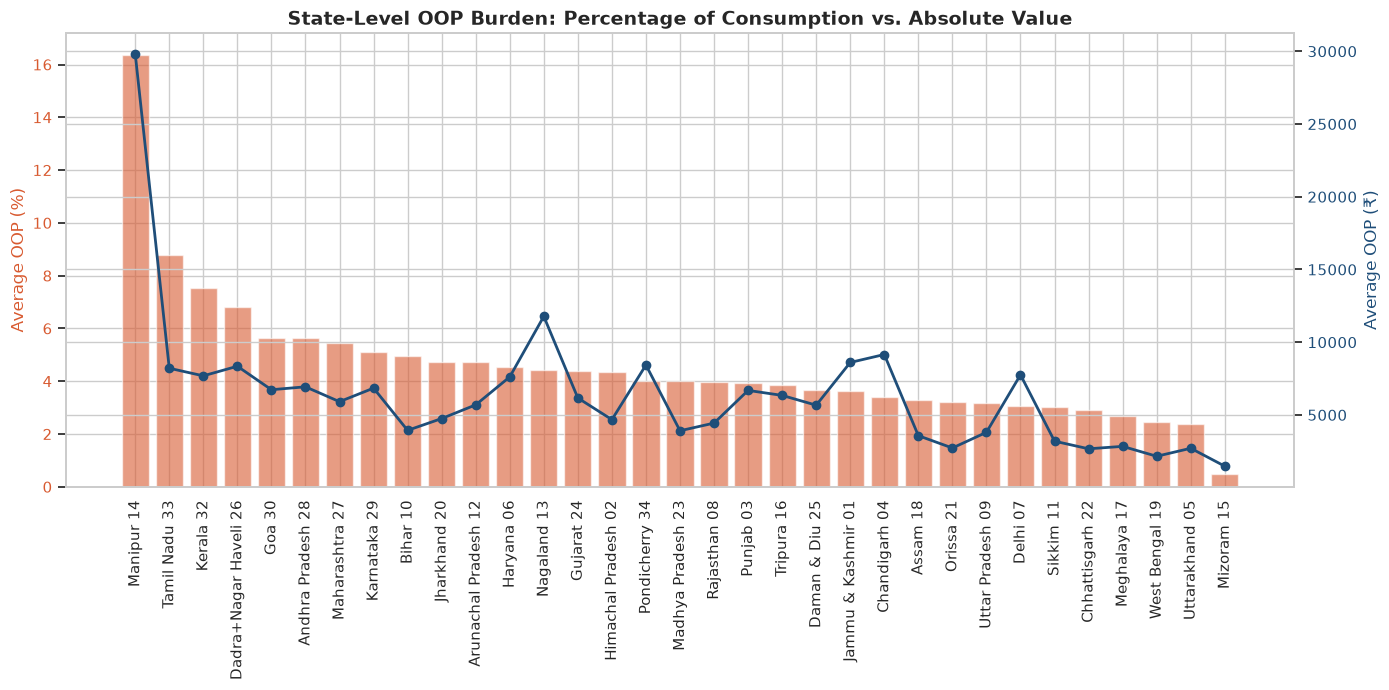


✓ Analysis printed and dual-axis plot saved to: all_india/plots/state_oop_burden_dual.png


In [45]:
ALL_INDIA_DIR = Path('all_india')
PLOT_DIR = ALL_INDIA_DIR / 'plots'
PLOT_DIR.mkdir(exist_ok=True)

# List all processed files
processed_files = list(ALL_INDIA_DIR.glob('final_mhi_dataset_*.csv'))
data_list = []

# Process each state
for file in processed_files:
    # Extract state name
    state_name = file.stem.replace('final_mhi_dataset_data_subset_', '')
    df = pd.read_csv(file)
    
    # Calculate OOP % share if columns exist (defined in Cell 12)
    if 'OOP_TOTAL' in df.columns and 'COTOTAL' in df.columns:
        # OOP Percentage: (OOP_TOTAL / COTOTAL) * 100
        df['OOP_PERCENT'] = (df['OOP_TOTAL'] / df['COTOTAL'].replace(0, float('nan'))) * 100
        
        data_list.append({
            'State': state_name,
            'Avg_OOP_Value': df['OOP_TOTAL'].mean(),
            'Avg_OOP_Percent': df['OOP_PERCENT'].mean()
        })

# Create DataFrame and sort for display
avg_df = pd.DataFrame(data_list).sort_values('Avg_OOP_Percent', ascending=False)

# 1. Print the data table
print("=== State-Level Average OOP (Absolute Value vs Percentage of Consumption) ===")
print(avg_df.to_string(index=False))

# 2. Dual-Axis Plotting
fig, ax1 = plt.subplots(figsize=(14, 7))

# Bar for Percentage
ax1.bar(avg_df['State'], avg_df['Avg_OOP_Percent'], color='#D85A30', alpha=0.6, label='OOP % of Consumption')
ax1.set_ylabel('Average OOP (%)', color='#D85A30', fontsize=12)
ax1.tick_params(axis='y', labelcolor='#D85A30')
ax1.tick_params(axis='x', rotation=90)

# Secondary axis for absolute value
ax2 = ax1.twinx()
ax2.plot(avg_df['State'], avg_df['Avg_OOP_Value'], color='#1F4E79', marker='o', linewidth=2, label='Average OOP (₹)')
ax2.set_ylabel('Average OOP (₹)', color='#1F4E79', fontsize=12)
ax2.tick_params(axis='y', labelcolor='#1F4E79')

plt.title('State-Level OOP Burden: Percentage of Consumption vs. Absolute Value', fontweight='bold', fontsize=14)
fig.tight_layout()

# Save
plot_path = PLOT_DIR / 'state_oop_burden_dual.png'
plt.savefig(plot_path, dpi=200)
plt.show()

print(f"\n✓ Analysis printed and dual-axis plot saved to: {plot_path}")